Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/2400 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

[OPTIMIZER] epoch_start=0 global_step=0 wrapped=AcceleratedOptimizer base=AdamW lr=0.0 id=126671276294608 hyperparams={'lr': 0.0, 'betas': (0.9, 0.95), 'eps': 1e-06, 'weight_decay': 0.1, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': True, 'initial_lr': 1e-05}
[OPTIMIZER_GROUP]   group[0] {'lr': 0.0, 'betas': (0.9, 0.95), 'eps': 1e-06, 'weight_decay': 0.1, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': True, 'initial_lr': 1e-05}
[SCHEDULER]   scheduler_last_lr=[0.0]
[PARAMS]   params_total=278,045,955 params_trainable=278,045,955


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro,Mse,Sse
1,1.102600,0.959644,0.626667,0.604680,0.694423,0.626667,0.191497,57.449129
2,0.713300,0.520236,0.800000,0.795960,0.802778,0.800000,0.094968,28.490396
3,0.531500,0.346469,0.876667,0.876356,0.876851,0.876667,0.061935,18.580486
4,0.354300,0.295564,0.903333,0.903482,0.903661,0.903333,0.052513,15.753961
5,0.301500,0.247801,0.913333,0.913416,0.913529,0.913333,0.043269,12.980804
6,0.231300,0.274552,0.926667,0.926187,0.926918,0.926667,0.045545,13.663487
7,0.212100,0.274805,0.920000,0.919568,0.919719,0.920000,0.044863,13.458924
8,0.182500,0.239395,0.923333,0.923173,0.923494,0.923333,0.040187,12.056002
9,0.155100,0.227443,0.930000,0.929683,0.929739,0.930000,0.037285,11.185448
10,0.135800,0.232988,0.946667,0.946611,0.946780,0.946667,0.035703,10.711030


[TRAINING_PERFORMANCE] epoch=1.0 tokens=0 time=18.44s tok/s=0.0 ex/s=0.00 peak_mem=5.23GiB lr=9.68e-06
[EVALUATION_PERFORMANCE] tokens=81920 time=0.17s tok/s=488474.0 ex/s=3816.20
[EVALUATION_PERFORMANCE] accuracy=0.6267 cost=$0.01 accuracy_per_$=58.63
[OPTIMIZER] epoch_start=1.0 global_step=75 wrapped=AcceleratedOptimizer base=AdamW lr=9.684361549497849e-06 id=126671276294608 hyperparams={'lr': 9.684361549497849e-06, 'betas': (0.9, 0.95), 'eps': 1e-06, 'weight_decay': 0.1, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': True, 'initial_lr': 1e-05}
[OPTIMIZER_GROUP]   group[0] {'lr': 9.684361549497849e-06, 'betas': (0.9, 0.95), 'eps': 1e-06, 'weight_decay': 0.1, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': True, 'initial_lr': 1e-05}
[SCHEDULER]   scheduler_last_lr=[9.684361549497849e-06]
[PARAMS]   pa

[EVALUATION_PERFORMANCE] tokens=81920 time=0.30s tok/s=269081.2 ex/s=2102.20
[EVALUATION_PERFORMANCE] accuracy=0.9033 cost=$0.29 accuracy_per_$=3.15

### XLM-ROBERTA-BASE EVALUATION METRICS ###
{'epoch': 10.0,
 'eval_accuracy': 0.9033333333333333,
 'eval_f1_macro': 0.9025645030799669,
 'eval_loss': 0.3294757008552551,
 'eval_mse': 0.052177879631374074,
 'eval_precision_macro': 0.9033520421565001,
 'eval_recall_macro': 0.9033333333333333,
 'eval_runtime': 0.3877,
 'eval_samples_per_second': 773.775,
 'eval_sse': 15.653363889412223,
 'eval_steps_per_second': 12.896}


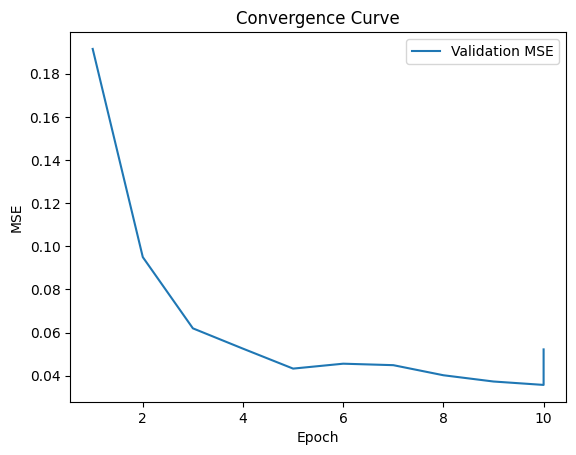

Saving the dataset (0/1 shards):   0%|          | 0/300 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/2400 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/300 [00:00<?, ? examples/s]

In [1]:
# A State Space Model Approach to Cross-Lingual Sentiment Analysis of Filipino Texts 


import os
import pandas as pd
import pprint

from pathlib import Path
from transformers import pipeline

from src.config import *
from src.metrics import evaluate_pipe
from src import (
    context,
    helper,
    sentiment, 
    utility, 
)

os.environ["HF_DATASETS_DISABLE_CACHING"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
helper.list_config()

if App.HAS_GPU:
    os.environ["MAMBA_USE_MAMBAPY"] = Mamba.FORCE_CUDA
    os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

if App.ACTION == "TRAIN":
    xlmr_context = context.setup_pipeline(Xlmr, require_translation = False)
    xlmr_trainer = sentiment.train(xlmr_context)

